# Informe de visualización avanzada

## Accidentes de tráfico en la ciudad de Madrid en 2025

**Autor:** Juan Carlos Carreira  
**Entrega:** Trabajo Fin de Módulo de Visualización Avanzada  
**Formato:** notebook autocontenido y reproducible  

Este trabajo analiza los accidentes de tráfico registrados en la ciudad de Madrid durante 2025. El objetivo no es construir un modelo predictivo, sino contar una historia de datos mediante visualizaciones claras, interpretaciones razonadas y conclusiones documentadas.

La pregunta que guía el informe es:

**¿Qué patrones temporales, territoriales y humanos ayudan a entender cómo se producen los accidentes de tráfico en Madrid y qué situaciones concentran mayor gravedad?**

## Resumen ejecutivo

El fichero contiene **51,067 registros de personas implicadas** y **21,688 accidentes únicos**. Esta diferencia es fundamental: una fila no representa necesariamente un accidente, sino una persona implicada en un accidente. Por eso el análisis trabaja con dos niveles:

1. **Nivel accidente**, usando `num_expediente` para contar cada siniestro una sola vez.
2. **Nivel persona implicada**, usando todas las filas para estudiar lesiones, sexo, edad, tipo de persona, alcohol, drogas y vehículo.

Los resultados principales son los siguientes:

- El periodo analizado cubre del **01/01/2025 al 31/12/2025**.
- El ámbito geográfico es la **ciudad de Madrid**, con registros distribuidos en **21 distritos**.
- El mes con más accidentes fue **octubre**, con **2,167 accidentes únicos**.
- El mes con menos accidentes fue **agosto**, con **1,143 accidentes únicos**.
- El día semanal con más accidentes fue **Viernes**, con **3,459 accidentes**.
- La hora con más accidentes fue la franja de las **14:00**, con **1,442 accidentes**.
- El distrito con más accidentes fue **CARABANCHEL**, con **1,536 accidentes**.
- El mecanismo más frecuente fue **Colisión fronto-lateral**, con **5,060 accidentes**.
- Las tres tipologías más repetidas concentran el **60.79 %** de los accidentes.
- Hubo **11,338 personas con algún tipo de lesión registrada**, el **22.20 %** de las personas implicadas.
- Hubo **493 personas heridas graves o fallecidas en 24 horas**, el **0.97 %** de las personas implicadas.
- Se registraron **34 fallecidos en 24 horas**.
- En **1,326 accidentes** aparece al menos una persona con positivo en alcohol, el **6.11 %** de los accidentes únicos.

La lectura global es clara: la siniestralidad se concentra en momentos de alta movilidad urbana, especialmente días laborables y horas de actividad intensa. Sin embargo, la gravedad no siempre se encuentra donde hay más accidentes. Peatones, motociclistas, ciclistas y usuarios de vehículos de movilidad urbana muestran mayor vulnerabilidad porque tienen menos protección física frente al impacto.

## Fuente de datos, alcance y reproducibilidad

### Fuente

El dataset procede del Portal de Datos Abiertos del Ayuntamiento de Madrid:

https://datos.madrid.es/dataset/300228-0-accidentes-trafico-detalle

El fichero utilizado en este trabajo es:

`300228-7-accidentes-trafico-detalle-xlsx.xlsx`

### Naturaleza del dato

El portal indica que el conjunto recoge accidentes de tráfico registrados por la Policía Municipal de Madrid y que se incluye un registro por persona implicada en el accidente. Esta característica obliga a separar el análisis de accidentes únicos del análisis de personas implicadas.

### Alcance temporal

Este notebook verifica el periodo directamente a partir del fichero cargado. En el dataset utilizado, las fechas van del 1 de enero de 2025 al 31 de diciembre de 2025.

### Alcance geográfico

El ámbito del análisis es la ciudad de Madrid. Las variables de distrito y coordenadas UTM permiten estudiar la distribución territorial dentro del municipio.

### Reproducibilidad

Para reproducir el trabajo se debe colocar este notebook en la misma carpeta que el fichero Excel y ejecutar todas las celdas de arriba abajo. Al final se genera una carpeta de resultados con gráficos, tablas y un archivo `requirements.txt` con las versiones de las librerías utilizadas.

## Paso 1. Preparar el entorno de trabajo

Esta primera celda importa las librerías necesarias, define la ruta del archivo de datos y crea las carpetas donde se guardarán las salidas. La práctica pide que el proceso sea reproducible, por lo que no se usan objetos creados manualmente fuera del notebook.

In [1]:
from pathlib import Path
from importlib.metadata import version
import warnings
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

archivo_datos = Path("300228-7-accidentes-trafico-detalle-xlsx.xlsx")
carpeta_resultados = Path("resultados_accidentes_madrid_2025")
carpeta_graficos = carpeta_resultados / "graficos"
carpeta_tablas = carpeta_resultados / "tablas"
carpeta_graficos.mkdir(parents=True, exist_ok=True)
carpeta_tablas.mkdir(parents=True, exist_ok=True)

La celda no produce una tabla porque su función es preparar el entorno. Si se ejecuta sin errores, el notebook ya tiene definidas las rutas de entrada y salida. Esta estructura evita depender de rutas absolutas del ordenador de una persona concreta.

## Paso 2. Cargar el dataset original

Esta celda lee el Excel original. El objetivo es comprobar cuántos registros y columnas contiene el archivo antes de realizar cualquier transformación.

In [2]:
df_original = pd.read_excel(archivo_datos)
resumen_carga = pd.DataFrame({
    "elemento": ["registros", "columnas"],
    "valor": [df_original.shape[0], df_original.shape[1]]
})
resumen_carga

,elemento,valor
0,registros,51067
1,columnas,19


El archivo original contiene **51,067 registros** y **28 columnas**. Esta cifra todavía no debe interpretarse como número de accidentes, porque el propio diseño del fichero trabaja a nivel de persona implicada. Un mismo `num_expediente` puede aparecer varias veces cuando intervienen varios conductores, pasajeros o peatones.

## Paso 3. Revisar las primeras filas y las variables disponibles

Antes de calcular indicadores, conviene observar la estructura del fichero. Esta celda muestra las primeras filas para confirmar que existen variables temporales, geográficas, de tipo de accidente, meteorología, vehículo, perfil de persona y lesividad.

In [3]:
df_original.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2025S000056,2025-01-01,00:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Ciclomotor,Conductor,De 30 a 34 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,442965.751,4477385.334,N,NaN
1,2025S000056,2025-01-01,00:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Turismo,Conductor,De 40 a 44 años,Hombre,14.0,Sin asistencia sanitaria,442965.751,4477385.334,N,NaN
2,2025S000056,2025-01-01,00:49:00,CALL. LOPEZ DE HOYOS / CALL. ROS DE OLANO,140,5,CHAMARTÍN,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 40 a 44 años,Mujer,14.0,Sin asistencia sanitaria,442965.751,4477385.334,N,NaN
3,2025S000057,2025-01-01,02:20:00,GTA. RIO ZANCARA / CALL. ARROYO DE POZUELO,1,9,MONCLOA-ARAVACA,Colisión lateral,Despejado,Turismo,Conductor,De 21 a 24 años,Hombre,NaN,NaN,433911.019,4478290.367,N,NaN
4,2025S000057,2025-01-01,02:20:00,GTA. RIO ZANCARA / CALL. ARROYO DE POZUELO,1,9,MONCLOA-ARAVACA,Colisión lateral,Despejado,Turismo,Conductor,De 45 a 49 años,Hombre,NaN,NaN,433911.019,4478290.367,N,NaN


La estructura confirma que el dataset permite construir una historia completa: cuándo ocurren los accidentes, dónde se concentran, qué tipo de accidente se registra, qué vehículos participan y qué consecuencias tienen sobre las personas implicadas. No se necesita crear un modelo complejo porque las variables ya permiten analizar patrones visuales.

## Paso 4. Limpiar y enriquecer los datos

Esta celda transforma el dataset para que pueda analizarse correctamente. Se crean variables de mes, día de la semana y hora; se normalizan campos con valores vacíos; se identifican positivos de alcohol y droga; se diferencian lesiones leves, graves y fallecimientos; y se agrupan vehículos en categorías más interpretables.

In [4]:
df = df_original.copy()
df.columns = [col.strip() for col in df.columns]
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

def extraer_hora(valor):
    if pd.isna(valor):
        return np.nan
    if hasattr(valor, "hour"):
        return valor.hour
    texto = str(valor)
    valor_convertido = pd.to_datetime(texto, format="%H:%M:%S", errors="coerce")
    if pd.isna(valor_convertido):
        return np.nan
    return valor_convertido.hour

def agrupar_vehiculo(valor):
    if pd.isna(valor):
        return "No informado"
    texto = str(valor).lower()
    if "turismo" in texto or "todo terreno" in texto:
        return "Turismo y todoterreno"
    if "motocicleta" in texto or "ciclomotor" in texto:
        return "Moto y ciclomotor"
    if "bicicleta" in texto:
        return "Bicicleta"
    if "vmu" in texto:
        return "VMU eléctrico"
    if "autob" in texto:
        return "Autobús"
    if "furgoneta" in texto:
        return "Furgoneta"
    if "camión" in texto or "tractocamión" in texto or "vehículo articulado" in texto:
        return "Vehículo pesado"
    return "Otros"

columnas_texto = ["distrito", "tipo_accidente", "estado_meteorológico", "tipo_vehiculo", "tipo_persona", "rango_edad", "sexo", "lesividad"]
for columna in columnas_texto:
    df[columna] = df[columna].fillna("No informado").astype(str).str.strip()

dias = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves", 4: "Viernes", 5: "Sábado", 6: "Domingo"}
meses = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}

df["hora_entera"] = df["hora"].apply(extraer_hora)
df["mes"] = df["fecha"].dt.month
df["mes_nombre"] = df["mes"].map(meses)
df["dia_semana_num"] = df["fecha"].dt.dayofweek
df["dia_semana"] = df["dia_semana_num"].map(dias)
df["fin_de_semana"] = df["dia_semana"].isin(["Sábado", "Domingo"])
df["alcohol_positivo"] = df["positiva_alcohol"].astype(str).str.upper().eq("S")
df["droga_positiva"] = df["positiva_droga"].fillna(0).astype(str).str.replace(".0", "", regex=False).eq("1")
df["con_lesion"] = df["cod_lesividad"].isin([1, 2, 3, 4, 5, 6, 7])
df["grave_o_fallecido"] = df["cod_lesividad"].isin([3, 4])
df["fallecido_24h"] = df["cod_lesividad"].eq(4)
df["grupo_vehiculo"] = df["tipo_vehiculo"].apply(agrupar_vehiculo)

La limpieza no elimina información relevante. El objetivo es hacer que los campos sean interpretables y comparables. La variable `con_lesion` permite separar a las personas con asistencia sanitaria registrada de aquellas sin lesión registrada. La variable `grave_o_fallecido` permite identificar los casos de mayor severidad.

## Paso 5. Crear la tabla de accidentes únicos

La variable clave es `num_expediente`. Para contar accidentes, se conserva una sola fila por expediente y se añaden indicadores agregados con el número de personas implicadas, lesionadas, graves o fallecidas, y la presencia de alcohol o droga en alguna persona del accidente.

In [5]:
accidentes = df.sort_values(["num_expediente", "fecha", "hora_entera"]).drop_duplicates("num_expediente").copy()
agregados_accidente = df.groupby("num_expediente").agg(
    personas_implicadas=("num_expediente", "size"),
    personas_lesionadas=("con_lesion", "sum"),
    personas_graves_o_fallecidas=("grave_o_fallecido", "sum"),
    fallecidos_24h=("fallecido_24h", "sum"),
    alcohol_accidente=("alcohol_positivo", "max"),
    droga_accidente=("droga_positiva", "max")
)
accidentes = accidentes.merge(agregados_accidente, left_on="num_expediente", right_index=True, how="left")
accidentes["tiene_lesionados"] = accidentes["personas_lesionadas"].gt(0)
accidentes["grave_o_mortal"] = accidentes["personas_graves_o_fallecidas"].gt(0)
indicadores_base = pd.DataFrame({
    "indicador": ["personas implicadas", "accidentes únicos", "personas medias por accidente", "fecha inicial", "fecha final", "distritos"],
    "valor": [len(df), len(accidentes), round(len(df) / len(accidentes), 2), df["fecha"].min().date(), df["fecha"].max().date(), accidentes["distrito"].nunique()]
})
indicadores_base.to_csv(carpeta_tablas / "indicadores_base.csv", index=False)
indicadores_base

,indicador,valor
0,personas implicadas,51067
1,accidentes únicos,21688
2,personas medias por accidente,2.35
3,fecha inicial,2025-01-01
4,fecha final,2025-12-31
5,distritos,21


El resultado muestra **21,688 accidentes únicos** frente a **51,067 registros de personas implicadas**. La media es de **2.35 personas por accidente**. Esta distinción evita una lectura equivocada: si se contaran filas directamente, se sobredimensionarían los accidentes con más personas implicadas.

## Paso 6. Control básico de calidad de datos

Esta celda revisa los valores nulos por columna. No se trata de eliminar columnas automáticamente, sino de conocer qué variables son más completas y cuáles requieren prudencia en la interpretación.

In [6]:
calidad = pd.DataFrame({
    "columna": df_original.columns,
    "nulos": df_original.isna().sum().values,
    "porcentaje_nulos": (df_original.isna().mean().values * 100).round(2)
}).sort_values("porcentaje_nulos", ascending=False)
calidad.to_csv(carpeta_tablas / "calidad_datos.csv", index=False)
calidad.head(10)

,columna,nulos,porcentaje_nulos
18,positiva_droga,50933,99.74
14,lesividad,22625,44.30
13,cod_lesividad,22625,44.30
8,estado_meteorológico,6050,11.85
9,tipo_vehiculo,429,0.84
17,positiva_alcohol,204,0.40
15,coordenada_x_utm,15,0.03
16,coordenada_y_utm,15,0.03
3,localizacion,3,0.01
0,num_expediente,0,0.00


La tabla permite identificar las variables que deben comentarse con más cuidado. Por ejemplo, la información de droga aparece muy incompleta porque solo se registra cuando existe un positivo. La lesividad también requiere prudencia porque no todos los registros tienen el mismo nivel de detalle. Por eso las conclusiones sobre gravedad se calculan a partir de códigos explícitos de lesión grave o fallecimiento, no a partir de supuestos.

## Paso 7. Evolución mensual de los accidentes

La primera visualización responde a una pregunta sencilla: si los accidentes se reparten de forma homogénea durante el año o si existen meses con mayor concentración.

,mes,mes_nombre,accidentes
0,1,Enero,1727
1,2,Febrero,1591
2,3,Marzo,2003
3,4,Abril,1750
4,5,Mayo,1842
5,6,Junio,1894
6,7,Julio,1735
7,8,Agosto,1143
8,9,Septiembre,1859
9,10,Octubre,2167


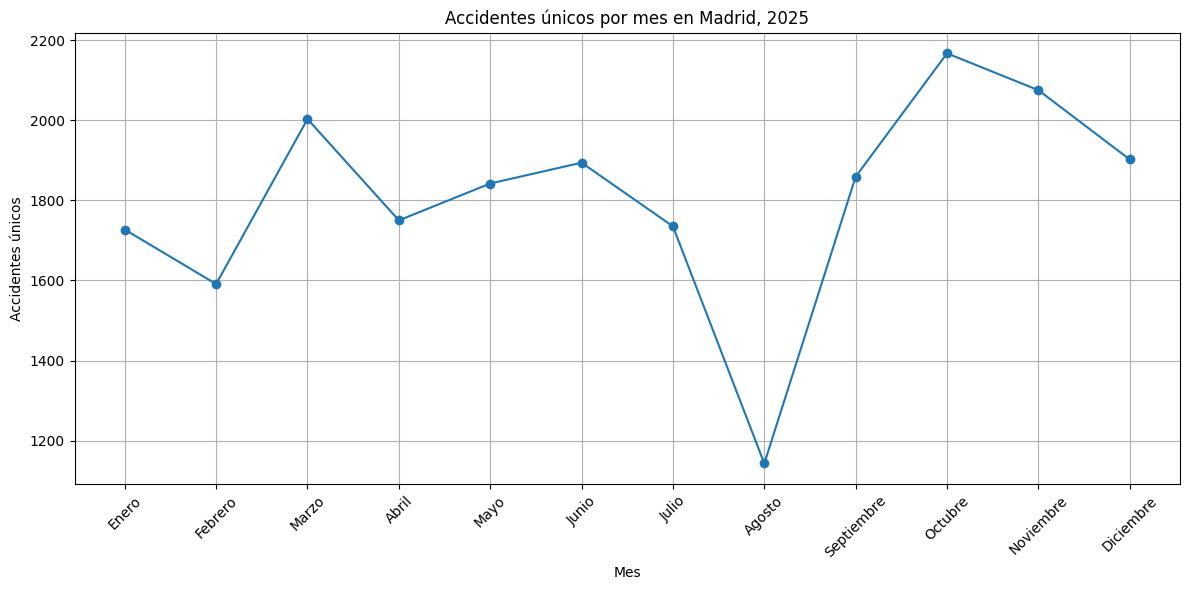

In [7]:
mensual = accidentes.groupby(["mes", "mes_nombre"]).size().reset_index(name="accidentes").sort_values("mes")
mensual.to_csv(carpeta_tablas / "accidentes_por_mes.csv", index=False)
display(mensual)
plt.figure(figsize=(12, 6))
plt.plot(mensual["mes_nombre"], mensual["accidentes"], marker="o")
plt.title("Accidentes únicos por mes en Madrid, 2025")
plt.xlabel("Mes")
plt.ylabel("Accidentes únicos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(carpeta_graficos / "01_accidentes_por_mes.png", dpi=200, bbox_inches="tight")
plt.show()

La serie mensual muestra un patrón compatible con la intensidad de la movilidad urbana. **Octubre** es el mes con más accidentes, con **2,167**, mientras que **agosto** es el mes con menos accidentes, con **1,143**.

Una explicación razonable es que agosto reduce desplazamientos laborales, escolares y de actividad económica por vacaciones. En cambio, los meses de otoño recuperan plenamente la actividad diaria. Esto no demuestra causalidad, porque el dataset no incluye intensidad de tráfico, pero sí sugiere que el volumen de desplazamientos es un factor relevante para entender la exposición al riesgo.

## Paso 8. Accidentes por día de la semana

Esta visualización compara los accidentes únicos por día. Permite comprobar si la siniestralidad está más asociada al patrón laboral o al patrón de fin de semana.

,dia_semana,accidentes
0,Lunes,3055
1,Martes,3304
2,Miércoles,3424
3,Jueves,3386
4,Viernes,3459
5,Sábado,2731
6,Domingo,2329


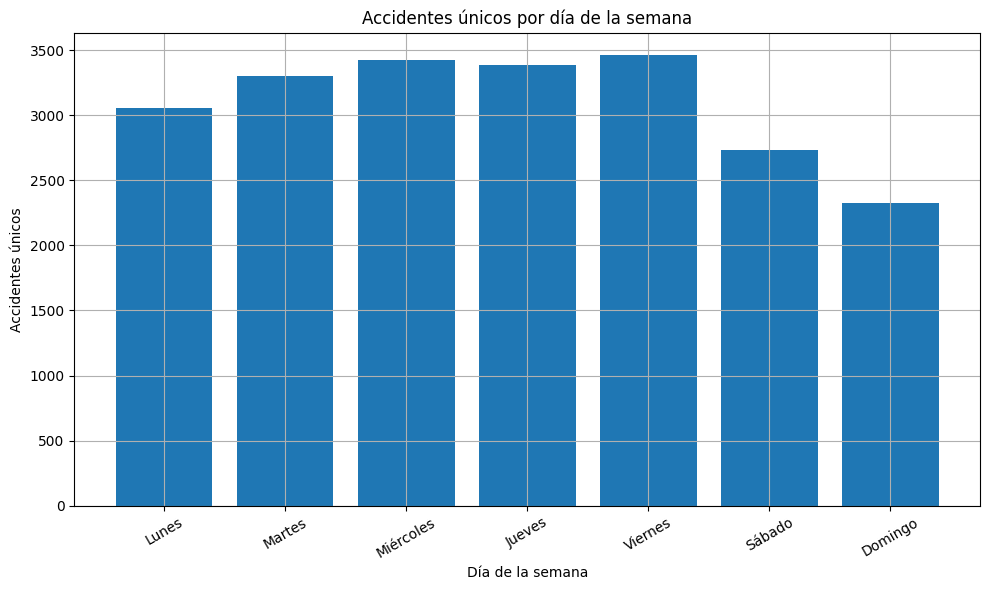

In [8]:
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
dia_semana = accidentes.groupby("dia_semana").size().reindex(orden_dias).reset_index(name="accidentes")
dia_semana.to_csv(carpeta_tablas / "accidentes_por_dia_semana.csv", index=False)
display(dia_semana)
plt.figure(figsize=(10, 6))
plt.bar(dia_semana["dia_semana"], dia_semana["accidentes"])
plt.title("Accidentes únicos por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Accidentes únicos")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(carpeta_graficos / "02_accidentes_por_dia_semana.png", dpi=200, bbox_inches="tight")
plt.show()

El día con más accidentes es **Viernes**, con **3,459** accidentes únicos. Los días laborables concentran más accidentes que el domingo, lo que encaja con una mayor exposición diaria: desplazamientos al trabajo, colegios, reparto, servicios, comercio y tráfico recurrente.

El dato no implica que conducir un viernes sea necesariamente más peligroso para cada conductor individual. Lo que muestra es que, en términos absolutos, ese día acumula más siniestros registrados. Para medir riesgo individual haría falta dividir los accidentes entre el volumen real de tráfico de cada día.

## Paso 9. Accidentes por hora del día

Esta celda analiza las horas con mayor concentración de accidentes. La hora es una variable clave porque la movilidad urbana cambia mucho entre madrugada, entrada al trabajo, mediodía, salida laboral y noche.

,hora_entera,accidentes
0,0,516
1,1,365
2,2,297
3,3,258
4,4,226
5,5,280
6,6,423
7,7,698
8,8,1021
9,9,1209


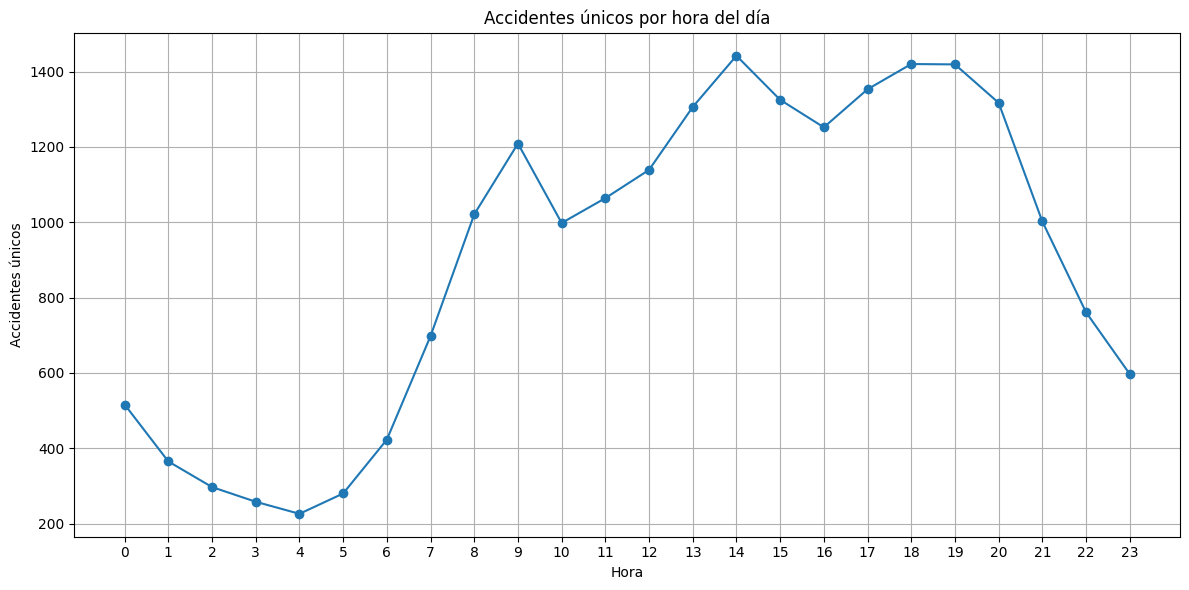

In [9]:
por_hora = accidentes.groupby("hora_entera").size().reset_index(name="accidentes").sort_values("hora_entera")
por_hora.to_csv(carpeta_tablas / "accidentes_por_hora.csv", index=False)
display(por_hora)
plt.figure(figsize=(12, 6))
plt.plot(por_hora["hora_entera"], por_hora["accidentes"], marker="o")
plt.title("Accidentes únicos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Accidentes únicos")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(carpeta_graficos / "03_accidentes_por_hora.png", dpi=200, bbox_inches="tight")
plt.show()

La hora con más accidentes es la franja de las **14:00**, con **1,442** accidentes. El patrón horario refleja la lógica de la ciudad: hay más accidentes cuando hay más vehículos, peatones, transporte público, reparto y actividad cotidiana compartiendo el espacio urbano.

La interpretación más importante es que el accidente no depende solo del comportamiento individual. También depende de la exposición: cuanto más tráfico y más interacciones hay, más oportunidades existen para que aparezcan conflictos como alcances, giros, cambios de carril o cruces.

## Paso 10. Mapa de calor día-hora

El mapa de calor combina dos dimensiones temporales. Es una de las visualizaciones más útiles del informe porque permite ver cuándo se concentran los accidentes sin separar artificialmente día y hora.

hora_entera,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
dia_semana,,,,,,,,,,,,,,,,,,,,,,,,
Lunes,71,34,31,24,17,25,44,100,168,198,149,164,176,193,210,183,186,210,220,213,174,122,80,63
Martes,43,25,14,16,11,19,46,127,208,231,206,179,172,200,223,215,203,215,243,227,182,120,100,79
Miércoles,52,30,32,27,20,28,51,129,203,246,158,186,200,184,223,197,187,224,245,247,213,139,106,97
Jueves,70,53,27,20,21,33,58,116,210,233,177,161,159,180,238,203,208,191,223,237,223,176,105,64
Viernes,80,38,35,32,30,37,52,96,145,173,149,158,160,208,254,267,233,253,213,199,211,177,146,113
Sábado,99,91,71,77,67,69,80,67,45,76,89,118,152,184,178,123,119,140,155,148,184,141,144,114
Domingo,101,94,87,62,60,69,92,63,42,52,70,98,120,157,116,137,116,120,121,148,130,127,80,67


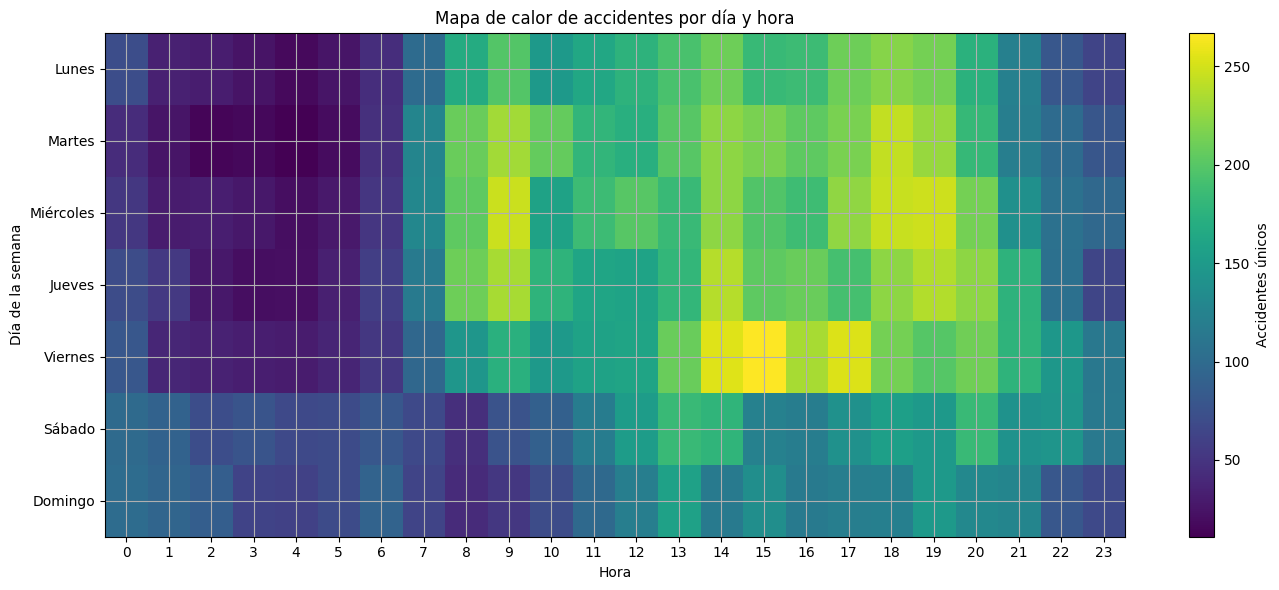

In [10]:
mapa_calor = pd.crosstab(accidentes["dia_semana"], accidentes["hora_entera"]).reindex(orden_dias)
mapa_calor.to_csv(carpeta_tablas / "mapa_calor_dia_hora.csv")
display(mapa_calor)
plt.figure(figsize=(14, 6))
plt.imshow(mapa_calor, aspect="auto")
plt.colorbar(label="Accidentes únicos")
plt.title("Mapa de calor de accidentes por día y hora")
plt.xlabel("Hora")
plt.ylabel("Día de la semana")
plt.xticks(range(24), range(24))
plt.yticks(range(len(mapa_calor.index)), mapa_calor.index)
plt.tight_layout()
plt.savefig(carpeta_graficos / "04_mapa_calor_dia_hora.png", dpi=200, bbox_inches="tight")
plt.show()

La combinación más intensa del mapa es **Viernes a las 15:00**, con **267 accidentes**. Esta concentración es coherente con una franja de alta actividad urbana, cuando coinciden desplazamientos laborales, compras, ocio, reparto y tráfico de salida.

El valor del mapa de calor está en que no solo dice qué día o qué hora tiene más accidentes, sino qué combinación concreta concentra más eventos. Esta lectura ayuda a orientar medidas preventivas de gestión del tráfico, vigilancia, señalización o campañas por franja horaria.

## Paso 11. Distribución por distritos

Esta celda muestra los distritos con más accidentes únicos. La lectura debe hacerse con cautela porque un distrito con más accidentes no es automáticamente más peligroso: también puede tener más población, más tráfico, vías principales, estaciones, zonas comerciales o mayor superficie.

,distrito,accidentes
0,CARABANCHEL,1536
1,PUENTE DE VALLECAS,1502
2,SALAMANCA,1499
3,CHAMARTÍN,1468
4,CIUDAD LINEAL,1339
5,FUENCARRAL-EL PARDO,1236
6,CENTRO,1235
7,MONCLOA-ARAVACA,1185
8,LATINA,1160
9,RETIRO,1074


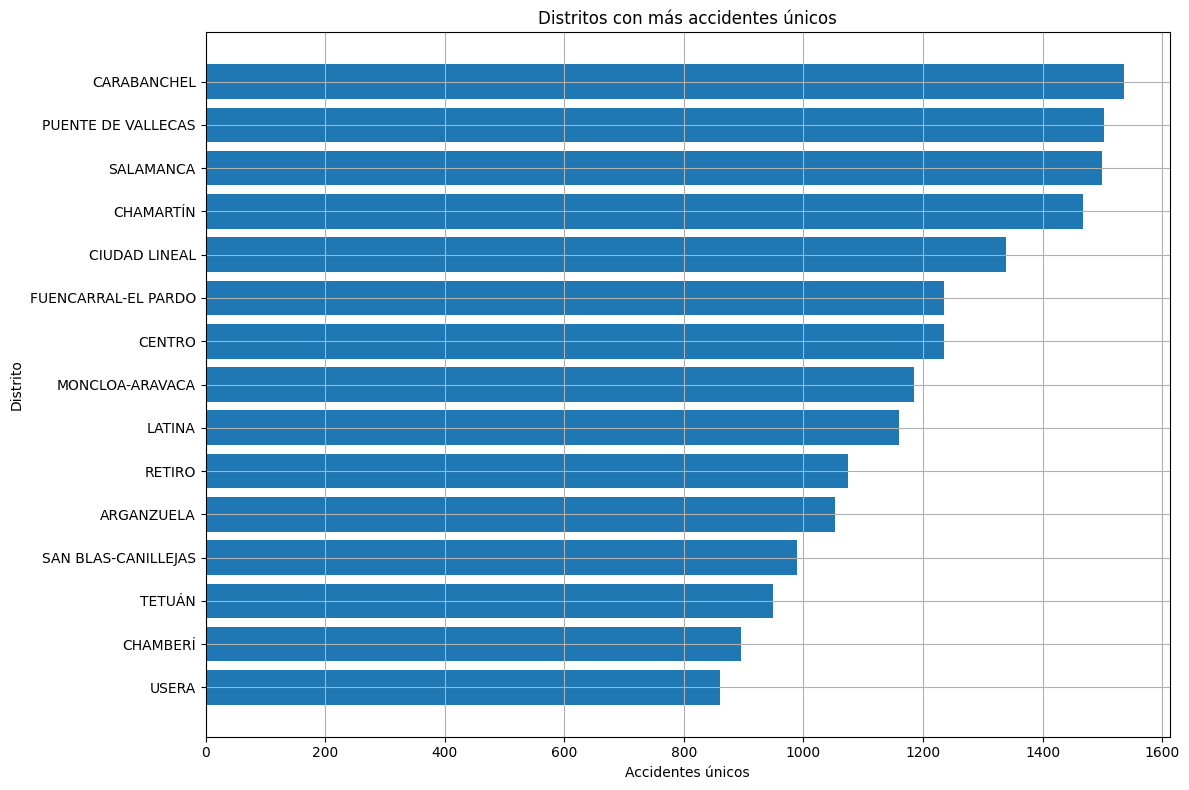

In [11]:
distritos = accidentes.groupby("distrito").size().sort_values(ascending=False).reset_index(name="accidentes")
distritos.to_csv(carpeta_tablas / "accidentes_por_distrito.csv", index=False)
display(distritos.head(15))
plt.figure(figsize=(12, 8))
plt.barh(distritos.head(15)["distrito"][::-1], distritos.head(15)["accidentes"][::-1])
plt.title("Distritos con más accidentes únicos")
plt.xlabel("Accidentes únicos")
plt.ylabel("Distrito")
plt.tight_layout()
plt.savefig(carpeta_graficos / "05_top_distritos.png", dpi=200, bbox_inches="tight")
plt.show()

El distrito con más accidentes es **CARABANCHEL**, con **1,536** accidentes únicos. La explicación más razonable no debe reducirse a que sea un distrito más peligroso, sino a que puede concentrar más desplazamientos, más vías de paso o más interacciones entre modos de transporte.

Para comparar riesgo real entre distritos harían falta denominadores: intensidad media de tráfico, población, kilómetros de vía, número de desplazamientos o superficie. Con los datos disponibles, el gráfico sirve para identificar concentración absoluta de accidentes, no riesgo ajustado.

## Paso 12. Distribución espacial aproximada

Las coordenadas UTM permiten observar la huella espacial de los registros. Esta visualización no sustituye a un mapa geográfico completo, pero ayuda a detectar concentración urbana y posibles corredores de mayor densidad.

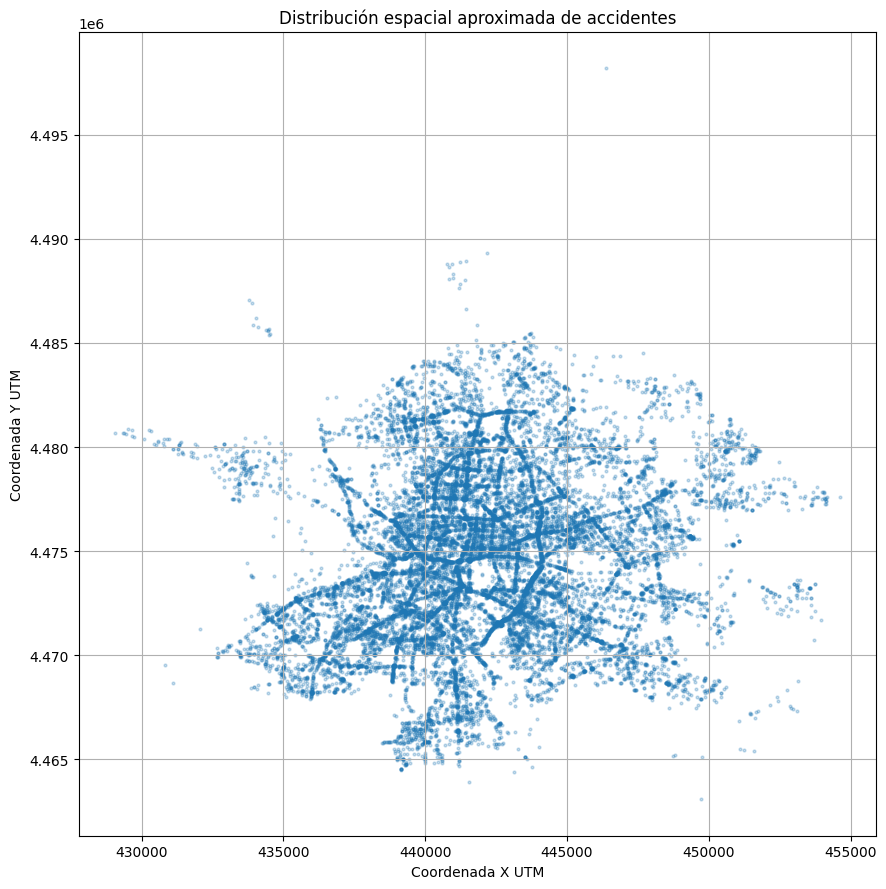

In [12]:
coordenadas = accidentes.dropna(subset=["coordenada_x_utm", "coordenada_y_utm"])
coordenadas.to_csv(carpeta_tablas / "accidentes_con_coordenadas.csv", index=False)
plt.figure(figsize=(9, 9))
plt.scatter(coordenadas["coordenada_x_utm"], coordenadas["coordenada_y_utm"], s=4, alpha=0.25)
plt.title("Distribución espacial aproximada de accidentes")
plt.xlabel("Coordenada X UTM")
plt.ylabel("Coordenada Y UTM")
plt.tight_layout()
plt.savefig(carpeta_graficos / "06_distribucion_espacial.png", dpi=200, bbox_inches="tight")
plt.show()

La nube de puntos confirma que los accidentes no se reparten de forma aleatoria. Se concentran en zonas con mayor actividad, ejes viarios y áreas densamente urbanas. Esta visualización aporta contexto territorial, pero no debe utilizarse para señalar puntos negros concretos sin un análisis adicional de red viaria y exposición al tráfico.

## Paso 13. Tipos de accidente más frecuentes

Esta sección se centra en las causas operativas observables. El dataset no contiene una columna llamada causa, por lo que no puede demostrar por qué ocurrió cada accidente. Lo que sí permite estudiar es el mecanismo registrado: colisión fronto-lateral, alcance, colisión lateral, caída, atropello, etc.

,tipo_accidente,accidentes,porcentaje,porcentaje_acumulado
0,Colisión fronto-lateral,5060,23.33,23.33
1,Alcance,4728,21.80,45.13
2,Colisión lateral,3397,15.66,60.79
3,Choque contra obstáculo fijo,3037,14.00,74.79
4,Caída,1939,8.94,83.73
5,Atropello a persona,1375,6.34,90.07
6,Otro,693,3.20,93.27
7,Colisión múltiple,603,2.78,96.05
8,Colisión frontal,472,2.18,98.23
9,Solo salida de la vía,201,0.93,99.16


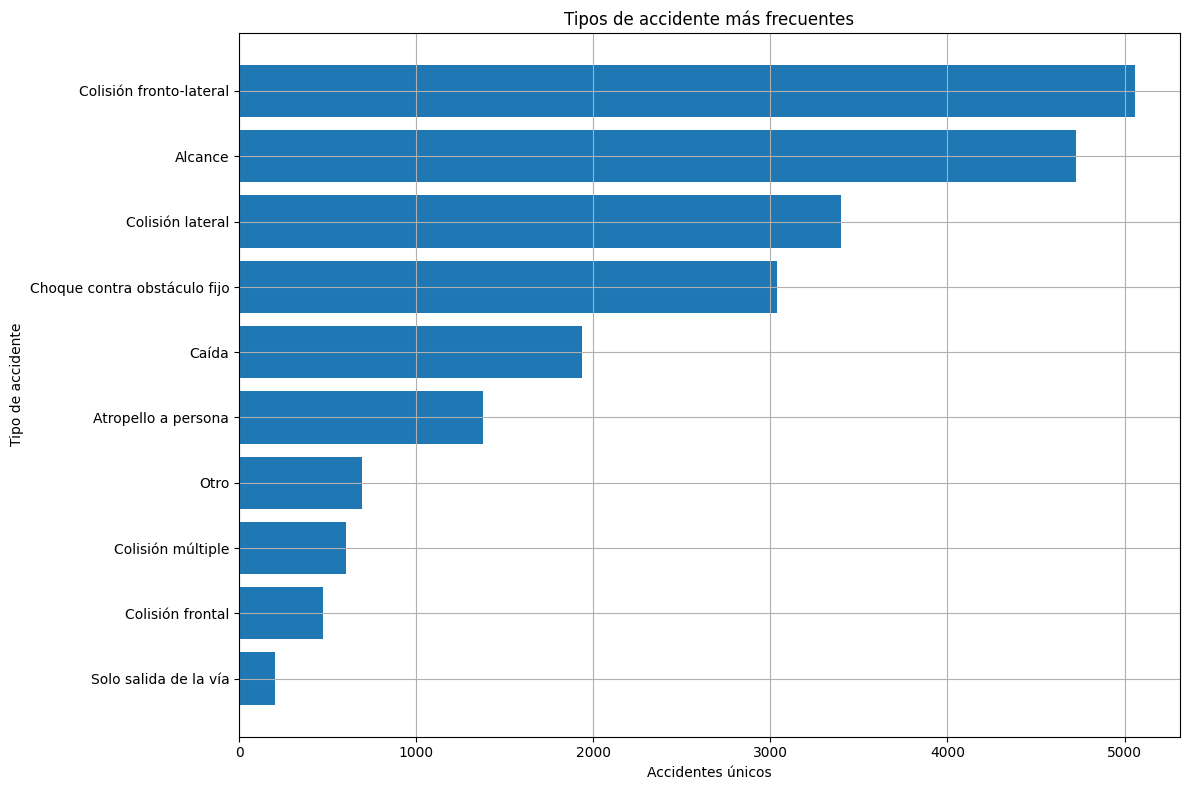

In [13]:
tipos_accidente = accidentes.groupby("tipo_accidente").size().sort_values(ascending=False).reset_index(name="accidentes")
tipos_accidente["porcentaje"] = (tipos_accidente["accidentes"] / len(accidentes) * 100).round(2)
tipos_accidente["porcentaje_acumulado"] = tipos_accidente["porcentaje"].cumsum().round(2)
tipos_accidente.to_csv(carpeta_tablas / "tipos_accidente.csv", index=False)
display(tipos_accidente)
plt.figure(figsize=(12, 8))
plt.barh(tipos_accidente.head(10)["tipo_accidente"][::-1], tipos_accidente.head(10)["accidentes"][::-1])
plt.title("Tipos de accidente más frecuentes")
plt.xlabel("Accidentes únicos")
plt.ylabel("Tipo de accidente")
plt.tight_layout()
plt.savefig(carpeta_graficos / "07_tipos_accidente.png", dpi=200, bbox_inches="tight")
plt.show()

El mecanismo más frecuente es **Colisión fronto-lateral**, con **5,060 accidentes**. Las tres primeras categorías concentran el **60.79 %** de los accidentes.

Esta concentración permite construir la explicación central del informe:

- **Colisión fronto-lateral:** suele estar asociada a conflictos en cruces, incorporaciones, giros o problemas de prioridad de paso.
- **Alcance:** suele aparecer cuando un vehículo impacta por detrás a otro, un patrón compatible con frenadas, congestión, distancia de seguridad insuficiente o distracciones.
- **Colisión lateral:** puede relacionarse con cambios de carril, circulación en paralelo, adelantamientos o incorporación a vías.

Estas son hipótesis interpretativas basadas en el tipo de accidente. El dataset no permite probar la causa exacta de cada caso, pero sí muestra que los conflictos entre trayectorias de vehículos son la estructura dominante de la siniestralidad registrada.

## Paso 14. Frecuencia y gravedad por tipo de accidente

No todos los tipos de accidente tienen la misma gravedad. Esta celda compara la frecuencia con la tasa de accidentes graves o mortales. La pregunta cambia: no solo qué ocurre más, sino qué tiene consecuencias más severas.

,tipo_accidente,accidentes,graves_o_mortales,tasa_grave_o_mortal
6,Colisión fronto-lateral,5060,130,2.57
0,Alcance,4728,40,0.85
7,Colisión lateral,3397,30,0.88
4,Choque contra obstáculo fijo,3037,22,0.72
3,Caída,1939,60,3.09
2,Atropello a persona,1375,161,11.71
10,Otro,693,3,0.43
8,Colisión múltiple,603,9,1.49
5,Colisión frontal,472,14,2.97
11,Solo salida de la vía,201,1,0.50


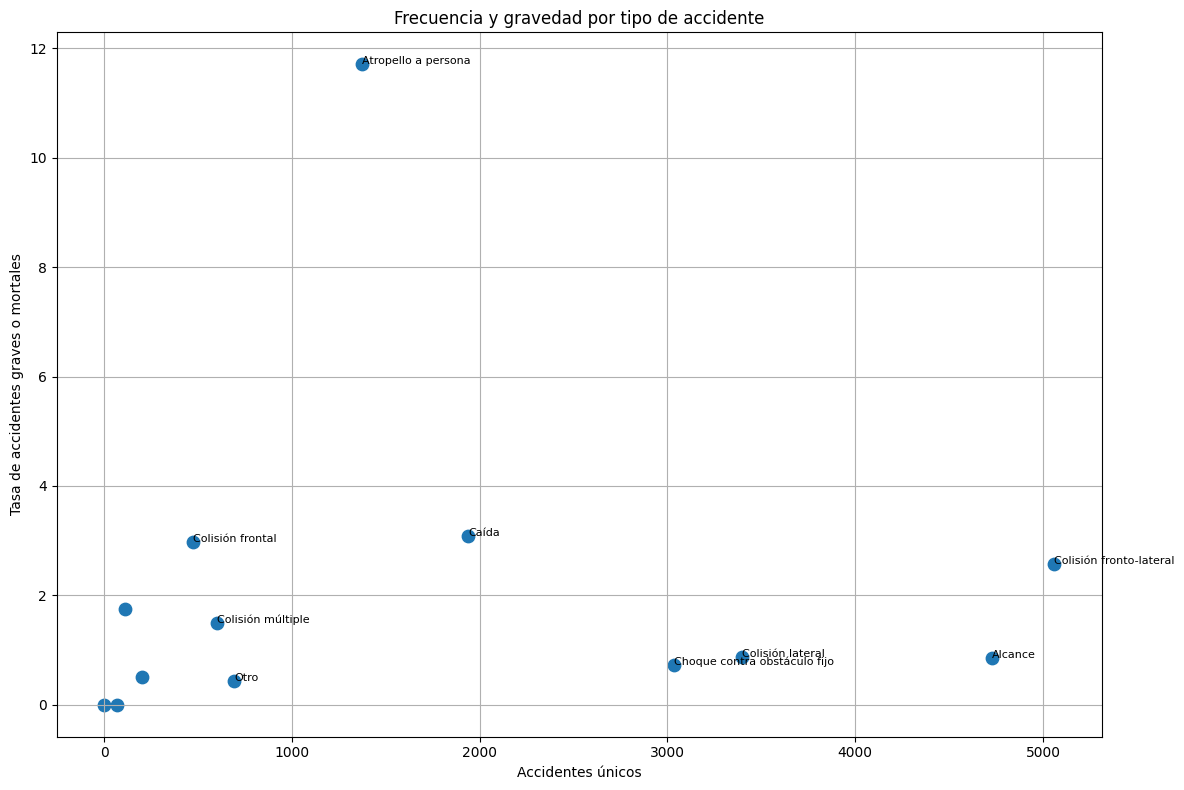

In [14]:
gravedad_tipo = accidentes.groupby("tipo_accidente").agg(
    accidentes=("num_expediente", "count"),
    graves_o_mortales=("grave_o_mortal", "sum"),
    tasa_grave_o_mortal=("grave_o_mortal", "mean")
).reset_index()
gravedad_tipo["tasa_grave_o_mortal"] = (gravedad_tipo["tasa_grave_o_mortal"] * 100).round(2)
gravedad_tipo = gravedad_tipo.sort_values("accidentes", ascending=False)
gravedad_tipo.to_csv(carpeta_tablas / "gravedad_por_tipo_accidente.csv", index=False)
display(gravedad_tipo)
plt.figure(figsize=(12, 8))
plt.scatter(gravedad_tipo["accidentes"], gravedad_tipo["tasa_grave_o_mortal"], s=80)
for _, fila in gravedad_tipo.iterrows():
    if fila["accidentes"] >= 400 or fila["tasa_grave_o_mortal"] >= 5:
        plt.text(fila["accidentes"], fila["tasa_grave_o_mortal"], fila["tipo_accidente"], fontsize=8)
plt.title("Frecuencia y gravedad por tipo de accidente")
plt.xlabel("Accidentes únicos")
plt.ylabel("Tasa de accidentes graves o mortales")
plt.tight_layout()
plt.savefig(carpeta_graficos / "08_frecuencia_gravedad_tipo.png", dpi=200, bbox_inches="tight")
plt.show()

El gráfico muestra una diferencia importante entre volumen y severidad. Los alcances y colisiones laterales son muy frecuentes, pero su tasa grave o mortal no es la más elevada. En cambio, el **atropello a persona** aparece con una tasa grave o mortal del **11.71 %**.

Esta diferencia es lógica desde el punto de vista físico: en una colisión entre vehículos existe una estructura de protección, cinturón, airbag y carrocería. En un atropello, el peatón recibe directamente la energía del impacto. Por eso el atropello puede ser menos frecuente que otros tipos de accidente, pero mucho más relevante en términos de daño humano.

## Paso 15. Vehículos implicados

Esta celda agrupa los vehículos para evitar una lectura demasiado fragmentada. El objetivo es comparar grandes grupos: turismos, motos, bicicletas, vehículos de movilidad urbana, furgonetas, autobuses y vehículos pesados.

,grupo_vehiculo,personas_implicadas,porcentaje
0,Turismo y todoterreno,36016,70.53
1,Moto y ciclomotor,5576,10.92
2,Furgoneta,3377,6.61
3,Autobús,1690,3.31
4,Vehículo pesado,1564,3.06
5,Bicicleta,1317,2.58
6,Otros,952,1.86
7,VMU eléctrico,575,1.13


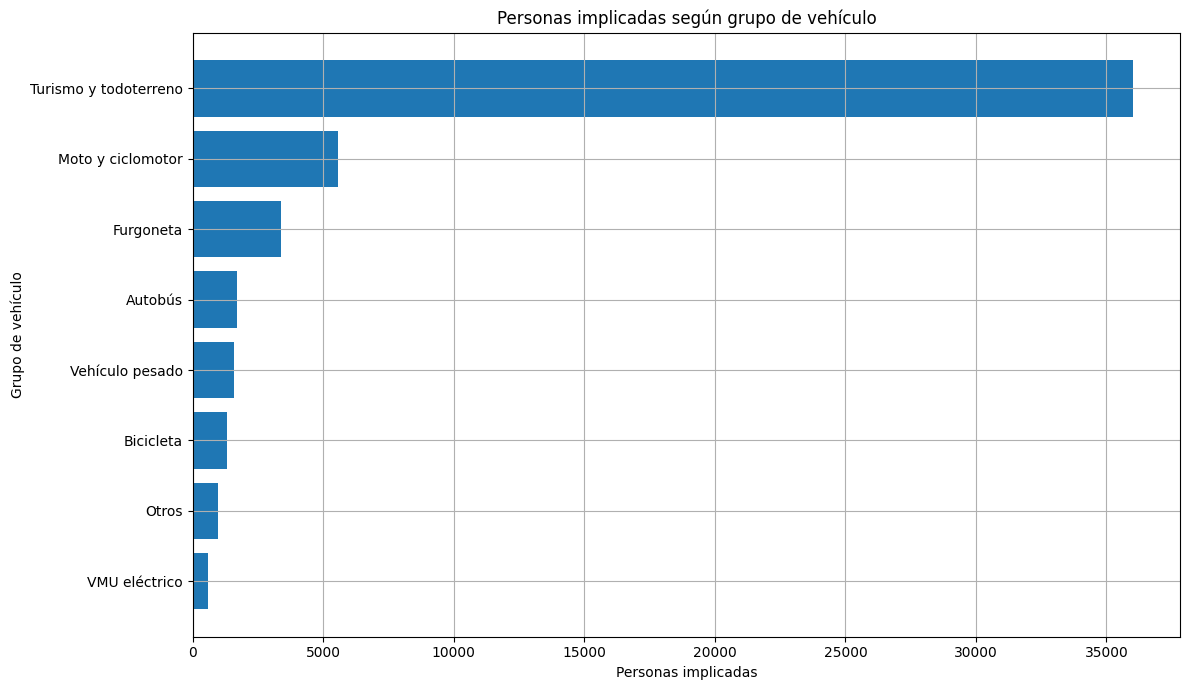

In [15]:
vehiculos = df.groupby("grupo_vehiculo").size().sort_values(ascending=False).reset_index(name="personas_implicadas")
vehiculos["porcentaje"] = (vehiculos["personas_implicadas"] / len(df) * 100).round(2)
vehiculos.to_csv(carpeta_tablas / "vehiculos_implicados.csv", index=False)
display(vehiculos)
plt.figure(figsize=(12, 7))
plt.barh(vehiculos["grupo_vehiculo"][::-1], vehiculos["personas_implicadas"][::-1])
plt.title("Personas implicadas según grupo de vehículo")
plt.xlabel("Personas implicadas")
plt.ylabel("Grupo de vehículo")
plt.tight_layout()
plt.savefig(carpeta_graficos / "09_vehiculos_implicados.png", dpi=200, bbox_inches="tight")
plt.show()

Los turismos y todoterrenos son el grupo más presente porque también son el modo motorizado más extendido en la ciudad. Sin embargo, presencia no significa vulnerabilidad. Para entender daño personal hay que combinar vehículo con lesividad, no solo contar cuántas veces aparece cada grupo.

## Paso 16. Lesividad por grupo de vehículo

Esta celda compara dos ideas distintas: la proporción de personas con alguna lesión y la proporción de personas heridas graves o fallecidas. Así se separa la exposición del daño.

,grupo_vehiculo,personas_implicadas,personas_con_lesion,personas_graves_o_fallecidas,tasa_con_lesion,tasa_grave_o_fallecido
3,Moto y ciclomotor,5576,3860,254,69.23,4.56
6,VMU eléctrico,575,413,18,71.83,3.13
1,Bicicleta,1317,985,36,74.79,2.73
4,Otros,952,165,11,17.33,1.16
0,Autobús,1690,408,14,24.14,0.83
7,Vehículo pesado,1564,70,12,4.48,0.77
2,Furgoneta,3377,363,16,10.75,0.47
5,Turismo y todoterreno,36016,5074,132,14.09,0.37


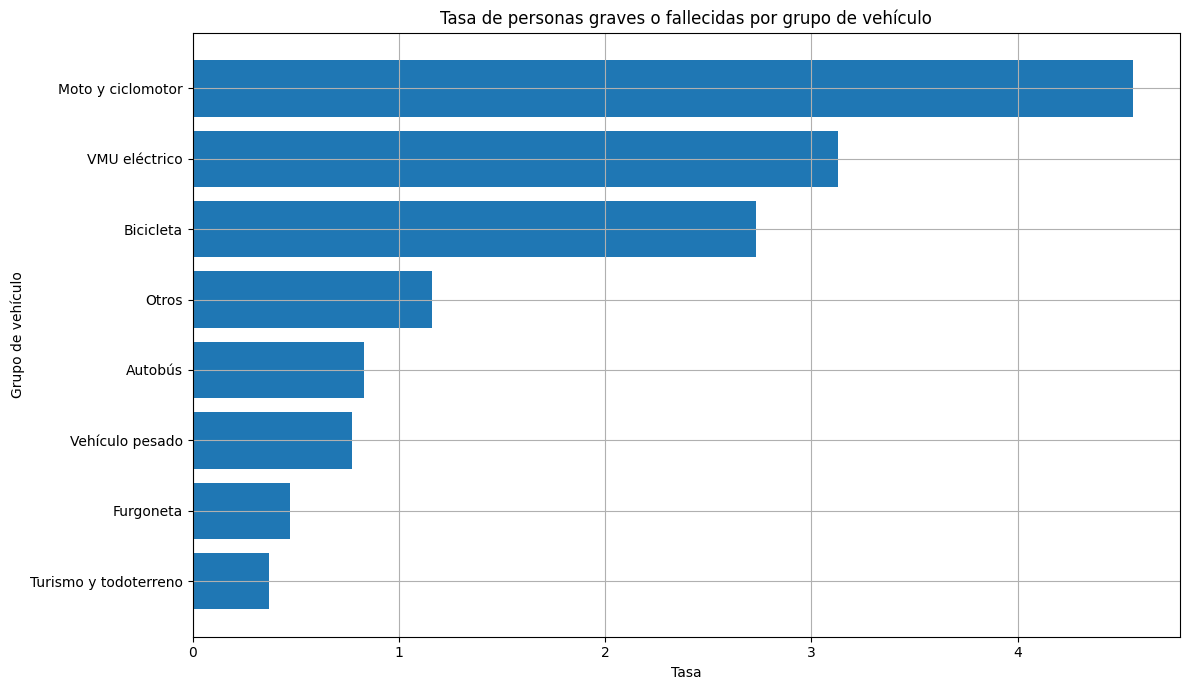

In [16]:
lesividad_vehiculo = df.groupby("grupo_vehiculo").agg(
    personas_implicadas=("num_expediente", "count"),
    personas_con_lesion=("con_lesion", "sum"),
    personas_graves_o_fallecidas=("grave_o_fallecido", "sum")
).reset_index()
lesividad_vehiculo["tasa_con_lesion"] = (lesividad_vehiculo["personas_con_lesion"] / lesividad_vehiculo["personas_implicadas"] * 100).round(2)
lesividad_vehiculo["tasa_grave_o_fallecido"] = (lesividad_vehiculo["personas_graves_o_fallecidas"] / lesividad_vehiculo["personas_implicadas"] * 100).round(2)
lesividad_vehiculo = lesividad_vehiculo.sort_values("tasa_grave_o_fallecido", ascending=False)
lesividad_vehiculo.to_csv(carpeta_tablas / "lesividad_por_vehiculo.csv", index=False)
display(lesividad_vehiculo)
plt.figure(figsize=(12, 7))
plt.barh(lesividad_vehiculo["grupo_vehiculo"][::-1], lesividad_vehiculo["tasa_grave_o_fallecido"][::-1])
plt.title("Tasa de personas graves o fallecidas por grupo de vehículo")
plt.xlabel("Tasa")
plt.ylabel("Grupo de vehículo")
plt.tight_layout()
plt.savefig(carpeta_graficos / "10_tasa_grave_por_vehiculo.png", dpi=200, bbox_inches="tight")
plt.show()

La interpretación cambia de forma clara: los turismos aparecen mucho en el dataset, pero los grupos más vulnerables son los que tienen menos protección física. Motocicletas, ciclomotores, bicicletas y vehículos de movilidad urbana presentan tasas de lesión grave o fallecimiento superiores a las de turismos y furgonetas.

La causa probable no es que sus usuarios cometan siempre más errores, sino que están más expuestos al daño cuando ocurre el accidente. La carrocería protege al ocupante de un coche; en moto, bici o patinete el cuerpo absorbe una parte mayor del impacto.

## Paso 17. Distribución general de la lesividad

Esta celda resume la consecuencia sanitaria de los accidentes sobre las personas implicadas. Se utiliza el nivel persona porque la lesividad se registra por individuo.

,lesividad,personas,porcentaje
0,No informado,22625,44.30
1,Sin asistencia sanitaria,17104,33.49
2,Asistencia sanitaria sólo en el lugar del acci...,5831,11.42
3,Ingreso inferior o igual a 24 horas,1846,3.61
4,Atención en urgencias sin posterior ingreso,1515,2.97
5,Asistencia sanitaria inmediata en centro de sa...,1109,2.17
6,Asistencia sanitaria ambulatoria con posterior...,544,1.07
7,Ingreso superior a 24 horas,459,0.90
8,Fallecido 24 horas,34,0.07


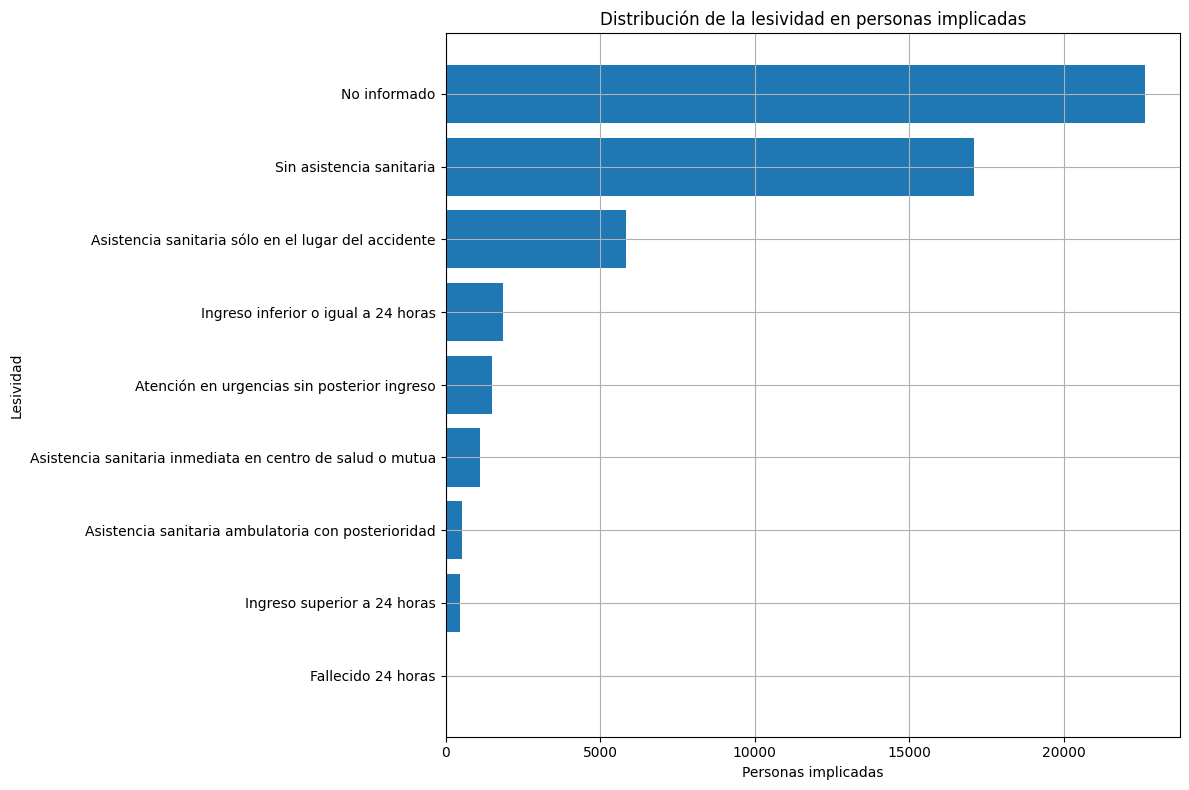

In [17]:
lesividad = df.groupby("lesividad").size().sort_values(ascending=False).reset_index(name="personas")
lesividad["porcentaje"] = (lesividad["personas"] / len(df) * 100).round(2)
lesividad.to_csv(carpeta_tablas / "distribucion_lesividad.csv", index=False)
display(lesividad)
plt.figure(figsize=(12, 8))
plt.barh(lesividad["lesividad"][::-1], lesividad["personas"][::-1])
plt.title("Distribución de la lesividad en personas implicadas")
plt.xlabel("Personas implicadas")
plt.ylabel("Lesividad")
plt.tight_layout()
plt.savefig(carpeta_graficos / "11_distribucion_lesividad.png", dpi=200, bbox_inches="tight")
plt.show()

En el conjunto analizado hay **11,338 personas con algún tipo de lesión registrada**, lo que representa el **22.20 %** de las personas implicadas. Los casos graves o fallecidos son **493**, el **0.97 %**, y se registran **34 fallecidos en 24 horas**.

Esta distribución muestra que la mayoría de registros no terminan en lesión grave, pero el impacto social de los accidentes no debe medirse solo por la frecuencia. Los casos graves y mortales son pocos en porcentaje, pero son los que más justifican intervenciones preventivas.

## Paso 18. Lesividad según tipo de persona

Esta celda compara conductores, pasajeros y peatones. La variable es especialmente importante porque no todos los implicados tienen la misma protección física ni ocupan el mismo espacio en la vía.

,tipo_persona,personas,personas_con_lesion,personas_graves_o_fallecidas,tasa_con_lesion,tasa_grave_o_fallecido
3,Peatón (atropello sc),2,2,1,100.00,50.00
2,Peatón,1679,1348,164,80.29,9.77
0,Conductor,40995,7773,299,18.96,0.73
1,Pasajero,8391,2215,29,26.40,0.35


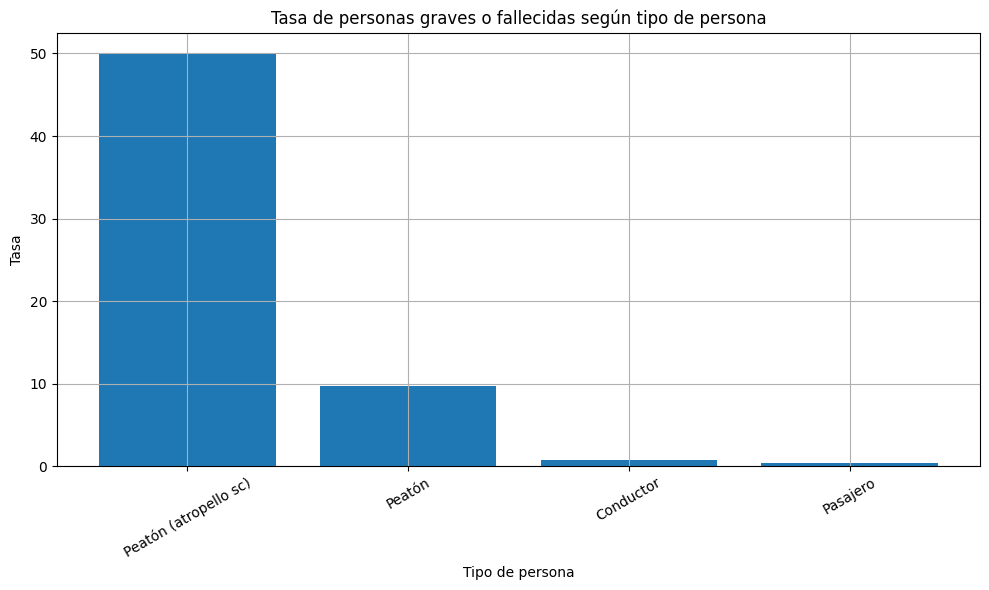

In [18]:
lesividad_persona = df.groupby("tipo_persona").agg(
    personas=("num_expediente", "count"),
    personas_con_lesion=("con_lesion", "sum"),
    personas_graves_o_fallecidas=("grave_o_fallecido", "sum")
).reset_index()
lesividad_persona["tasa_con_lesion"] = (lesividad_persona["personas_con_lesion"] / lesividad_persona["personas"] * 100).round(2)
lesividad_persona["tasa_grave_o_fallecido"] = (lesividad_persona["personas_graves_o_fallecidas"] / lesividad_persona["personas"] * 100).round(2)
lesividad_persona = lesividad_persona.sort_values("tasa_grave_o_fallecido", ascending=False)
lesividad_persona.to_csv(carpeta_tablas / "lesividad_por_tipo_persona.csv", index=False)
display(lesividad_persona)
plt.figure(figsize=(10, 6))
plt.bar(lesividad_persona["tipo_persona"], lesividad_persona["tasa_grave_o_fallecido"])
plt.title("Tasa de personas graves o fallecidas según tipo de persona")
plt.xlabel("Tipo de persona")
plt.ylabel("Tasa")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(carpeta_graficos / "12_tasa_grave_por_tipo_persona.png", dpi=200, bbox_inches="tight")
plt.show()

Los peatones presentan una tasa de gravedad muy superior a conductores y pasajeros. En el grupo `Peatón`, la tasa de grave o fallecido es aproximadamente **9.77 %**.

La explicación es estructural: el peatón carece de protección frente a un vehículo. Esta es una de las conclusiones más importantes del informe: la prevención debe priorizar no solo los lugares con más accidentes, sino las situaciones donde el daño potencial es mayor.

## Paso 19. Edad y sexo de las personas implicadas

Esta celda analiza el perfil demográfico de las personas implicadas. No busca responsabilizar a grupos concretos, sino describir qué perfiles aparecen con más frecuencia en los registros.

sexo,Desconocido,Hombre,Mujer
rango_edad,,,
Menor de 5 años,0,242,242
De 6 a 9 años,0,165,135
De 10 a 14 años,0,270,243
De 15 a 17 años,0,255,183
De 18 a 20 años,0,1085,562
De 21 a 24 años,1,2322,1073
De 25 a 29 años,0,3288,1592
De 30 a 34 años,2,3349,1694
De 35 a 39 años,0,3078,1537


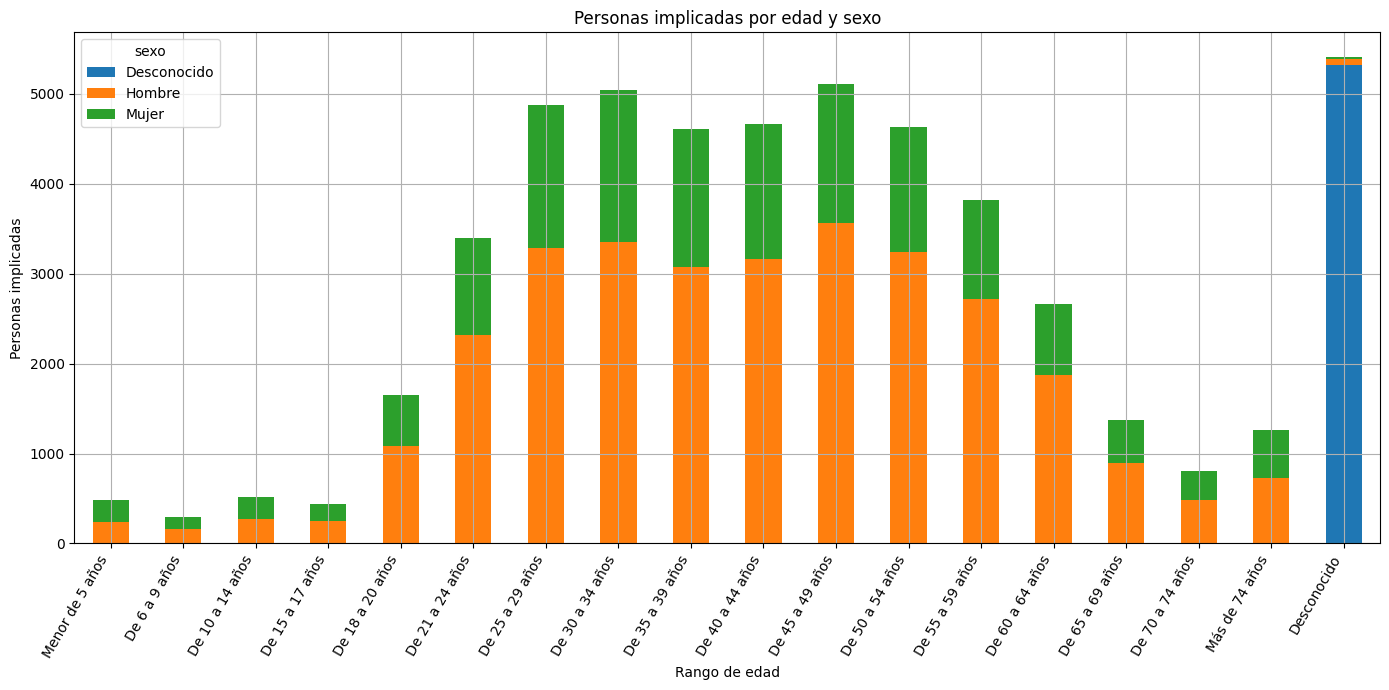

In [19]:
orden_edad = ["Menor de 5 años", "De 6 a 9 años", "De 10 a 14 años", "De 15 a 17 años", "De 18 a 20 años", "De 21 a 24 años", "De 25 a 29 años", "De 30 a 34 años", "De 35 a 39 años", "De 40 a 44 años", "De 45 a 49 años", "De 50 a 54 años", "De 55 a 59 años", "De 60 a 64 años", "De 65 a 69 años", "De 70 a 74 años", "Más de 74 años", "Desconocido"]
edad_sexo = pd.crosstab(df["rango_edad"], df["sexo"]).reindex(orden_edad).fillna(0).astype(int)
edad_sexo.to_csv(carpeta_tablas / "edad_y_sexo.csv")
display(edad_sexo)
edad_sexo.plot(kind="bar", stacked=True, figsize=(14, 7))
plt.title("Personas implicadas por edad y sexo")
plt.xlabel("Rango de edad")
plt.ylabel("Personas implicadas")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(carpeta_graficos / "13_edad_y_sexo.png", dpi=200, bbox_inches="tight")
plt.show()

Los grupos de edad adulta concentran gran parte de las personas implicadas, lo que resulta coherente con una mayor exposición como conductores y usuarios habituales de la vía. El valor `Desconocido` debe mantenerse visible porque forma parte de la calidad del dato y evita ocultar información incompleta.

Este gráfico describe presencia en el dataset, no riesgo individual. Para afirmar que una edad tiene más riesgo harían falta datos de población conductora, kilómetros recorridos o número de desplazamientos por grupo de edad.

## Paso 20. Alcohol por hora y día

Esta celda estudia la presencia de positivos en alcohol a nivel de accidente. Se considera que un accidente tiene alcohol positivo si al menos una persona implicada registra positivo.

,hora_entera,accidentes,accidentes_con_alcohol,tasa_alcohol
0,0,516,83,16.09
1,1,365,77,21.10
2,2,297,73,24.58
3,3,258,92,35.66
4,4,226,76,33.63
5,5,280,74,26.43
6,6,423,99,23.40
7,7,698,52,7.45
8,8,1021,27,2.64
9,9,1209,29,2.40


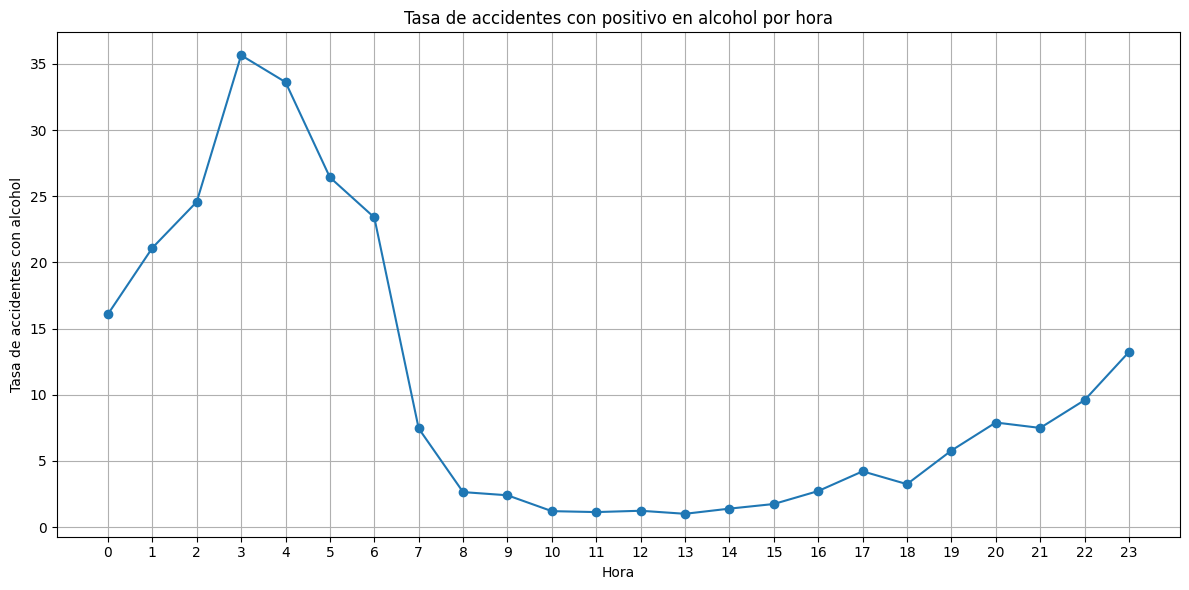

In [20]:
alcohol_hora = accidentes.groupby("hora_entera").agg(
    accidentes=("num_expediente", "count"),
    accidentes_con_alcohol=("alcohol_accidente", "sum"),
    tasa_alcohol=("alcohol_accidente", "mean")
).reset_index()
alcohol_hora["tasa_alcohol"] = (alcohol_hora["tasa_alcohol"] * 100).round(2)
alcohol_hora.to_csv(carpeta_tablas / "alcohol_por_hora.csv", index=False)
display(alcohol_hora)
plt.figure(figsize=(12, 6))
plt.plot(alcohol_hora["hora_entera"], alcohol_hora["tasa_alcohol"], marker="o")
plt.title("Tasa de accidentes con positivo en alcohol por hora")
plt.xlabel("Hora")
plt.ylabel("Tasa de accidentes con alcohol")
plt.xticks(range(24))
plt.tight_layout()
plt.savefig(carpeta_graficos / "14_alcohol_por_hora.png", dpi=200, bbox_inches="tight")
plt.show()

En el conjunto completo, **1,326 accidentes** presentan al menos un positivo en alcohol, el **6.11 %** de los accidentes únicos. La tasa más alta aparece a las **3:00**, con un **35.66 %**.

Este patrón es muy diferente al de la frecuencia general de accidentes. La mayoría de accidentes se concentra en horas de alta movilidad, pero el alcohol se concentra en la madrugada. La explicación más razonable es la relación con ocio nocturno, menor tráfico y mayor probabilidad de conducción bajo efectos del alcohol. De nuevo, el dataset muestra asociación, no prueba causal individual.

## Paso 21. Alcohol por día de la semana

Esta celda complementa el análisis anterior. Si la hipótesis de ocio nocturno es razonable, la tasa de alcohol debería aumentar en fin de semana.

,dia_semana,accidentes,accidentes_con_alcohol,tasa_alcohol
0,Lunes,3055,116,3.80
1,Martes,3304,93,2.81
2,Miércoles,3424,134,3.91
3,Jueves,3386,150,4.43
4,Viernes,3459,194,5.61
5,Sábado,2731,318,11.64
6,Domingo,2329,321,13.78


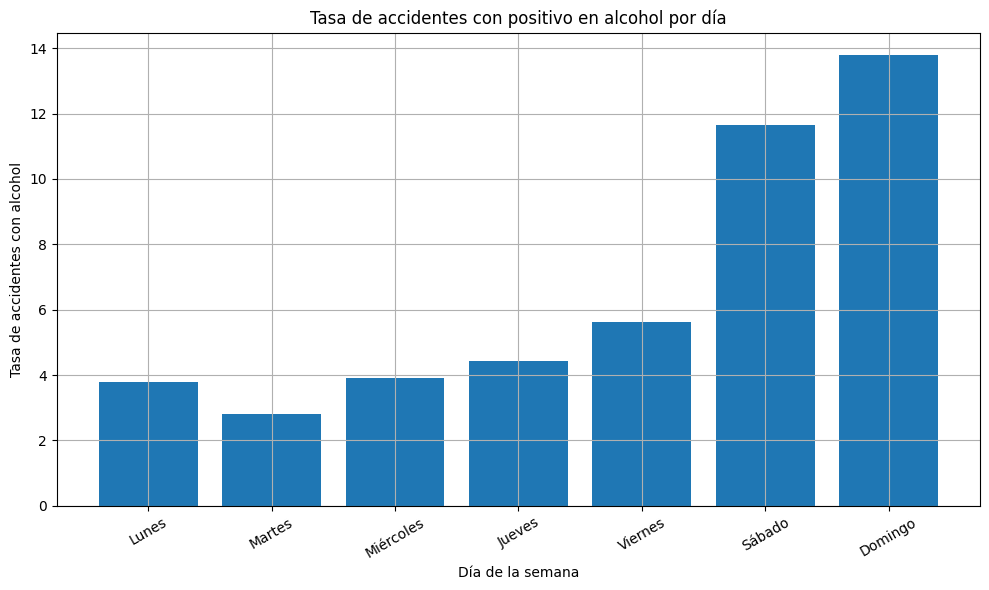

In [21]:
alcohol_dia = accidentes.groupby("dia_semana").agg(
    accidentes=("num_expediente", "count"),
    accidentes_con_alcohol=("alcohol_accidente", "sum"),
    tasa_alcohol=("alcohol_accidente", "mean")
).reindex(orden_dias).reset_index()
alcohol_dia["tasa_alcohol"] = (alcohol_dia["tasa_alcohol"] * 100).round(2)
alcohol_dia.to_csv(carpeta_tablas / "alcohol_por_dia.csv", index=False)
display(alcohol_dia)
plt.figure(figsize=(10, 6))
plt.bar(alcohol_dia["dia_semana"], alcohol_dia["tasa_alcohol"])
plt.title("Tasa de accidentes con positivo en alcohol por día")
plt.xlabel("Día de la semana")
plt.ylabel("Tasa de accidentes con alcohol")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(carpeta_graficos / "15_alcohol_por_dia.png", dpi=200, bbox_inches="tight")
plt.show()

El día con mayor tasa de accidentes con alcohol es **Domingo**, con un **13.78 %**. Esta lectura refuerza la diferencia entre frecuencia y factor asociado: los días laborables pueden tener más accidentes en número absoluto, pero el fin de semana concentra más presencia relativa de alcohol.

La conclusión preventiva es distinta para cada patrón. Para las horas punta, las medidas se orientan a gestión del tráfico y reducción de conflictos. Para la madrugada y el fin de semana, la prevención pasa más por controles, alternativas de transporte y reducción de conducción bajo consumo de alcohol.

## Paso 22. Meteorología

Esta celda analiza el estado meteorológico registrado. Es una variable útil, pero debe interpretarse con especial cuidado porque no tenemos el número total de horas o desplazamientos bajo cada condición meteorológica.

,estado_meteorológico,accidentes,accidentes_graves_o_mortales,tasa_grave_o_mortal
0,Despejado,14947,393,2.63
5,No informado,2707,0,0.00
3,Lluvia débil,1759,32,1.82
6,Nublado,1717,43,2.50
2,LLuvia intensa,394,3,0.76
7,Se desconoce,157,1,0.64
1,Granizando,6,0,0.00
4,Nevando,1,0,0.00


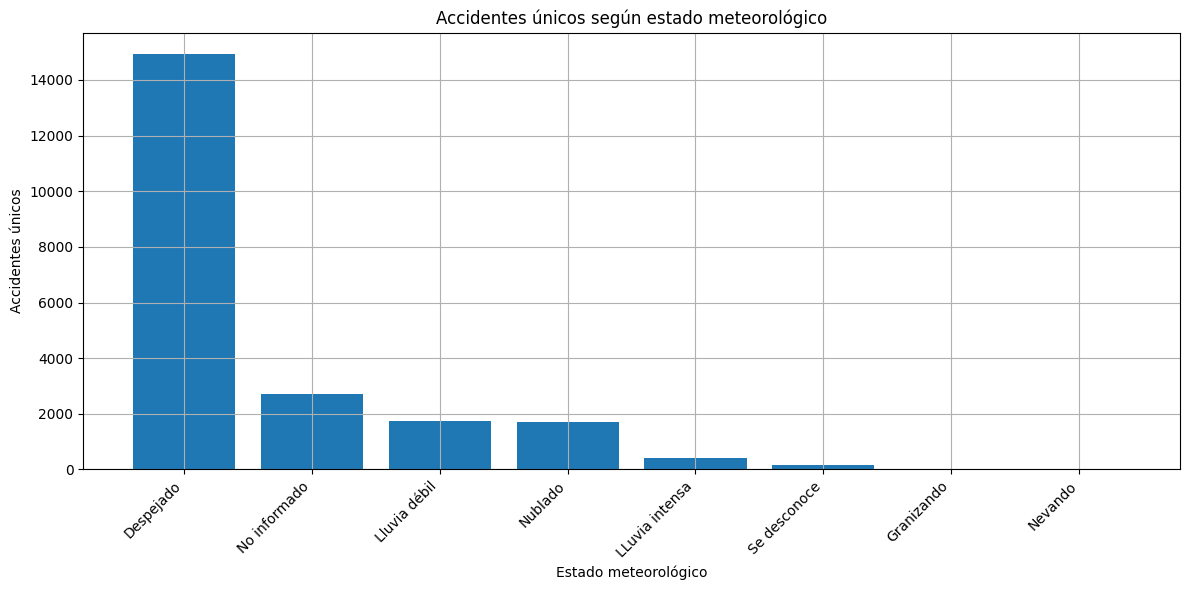

In [22]:
meteorologia = accidentes.groupby("estado_meteorológico").agg(
    accidentes=("num_expediente", "count"),
    accidentes_graves_o_mortales=("grave_o_mortal", "sum"),
    tasa_grave_o_mortal=("grave_o_mortal", "mean")
).reset_index()
meteorologia["tasa_grave_o_mortal"] = (meteorologia["tasa_grave_o_mortal"] * 100).round(2)
meteorologia = meteorologia.sort_values("accidentes", ascending=False)
meteorologia.to_csv(carpeta_tablas / "meteorologia.csv", index=False)
display(meteorologia)
plt.figure(figsize=(12, 6))
plt.bar(meteorologia["estado_meteorológico"], meteorologia["accidentes"])
plt.title("Accidentes únicos según estado meteorológico")
plt.xlabel("Estado meteorológico")
plt.ylabel("Accidentes únicos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(carpeta_graficos / "16_meteorologia_accidentes.png", dpi=200, bbox_inches="tight")
plt.show()

La mayor parte de los accidentes se registra con tiempo **Despejado**, con **14,947 accidentes**, el **68.92 %** del total. Esto no significa que el tiempo despejado sea más peligroso. Lo más probable es que haya más horas y más desplazamientos en condiciones despejadas.

Para medir el riesgo meteorológico real haría falta comparar accidentes con exposición: número de desplazamientos o kilómetros recorridos bajo lluvia, despejado, nublado, nieve o granizo. Con este dataset solo se puede afirmar dónde se registran más accidentes, no qué meteorología multiplica el riesgo.

## Paso 23. Conclusiones finales

El análisis permite extraer conclusiones útiles sin construir modelos complejos:

1. **La siniestralidad está muy vinculada a la exposición urbana.** Los días laborables, las horas de actividad y los distritos con más movimiento concentran más accidentes.

2. **Las causas operativas más comunes son conflictos entre trayectorias de vehículos.** Las colisiones fronto-laterales, alcances y colisiones laterales explican la mayor parte de los accidentes. Esto apunta a cruces, giros, distancia de seguridad, cambios de carril, incorporaciones y congestión como contextos prioritarios de prevención.

3. **Frecuencia y gravedad no son lo mismo.** Algunos tipos de accidente son muy frecuentes pero relativamente menos graves, mientras que el atropello tiene una tasa de gravedad mucho mayor.

4. **La vulnerabilidad física es clave.** Peatones, motociclistas, ciclistas y usuarios de vehículos de movilidad urbana presentan mayor lesividad porque tienen menos protección frente al impacto.

5. **El alcohol tiene un patrón temporal propio.** No coincide con las horas de más accidentes, sino con la madrugada y el fin de semana, lo que sugiere una prevención específica: controles, transporte alternativo y campañas orientadas al ocio nocturno.

6. **La meteorología debe analizarse con prudencia.** Que haya más accidentes con tiempo despejado no implica mayor peligrosidad del buen tiempo; probablemente refleja mayor exposición.

La recomendación principal sería combinar dos líneas de actuación: por un lado, medidas de gestión del tráfico en horas y zonas de alta concentración; por otro, medidas de protección de usuarios vulnerables y reducción de conductas de alto riesgo como el alcohol en fines de semana y madrugada.

## Paso 24. Limitaciones del análisis

Este informe es autocontenido, pero tiene limitaciones que deben documentarse:

- El dataset no incluye intensidad de tráfico, por lo que no se puede calcular riesgo por kilómetro recorrido o por desplazamiento.
- El dataset no incluye una causa policial detallada del accidente, sino una tipología del siniestro. Por eso se habla de mecanismos o factores asociados, no de causalidad demostrada.
- Algunos campos presentan valores no informados, especialmente en variables como droga o lesividad.
- Las comparaciones entre distritos no están ajustadas por población, superficie, longitud de vías o volumen de tráfico.
- Las coordenadas UTM permiten una visualización espacial aproximada, pero no sustituyen a un análisis geográfico completo sobre red viaria.

Estas limitaciones no invalidan el análisis. Al contrario, delimitan correctamente qué se puede afirmar con los datos disponibles y qué requeriría información adicional.

## Paso 25. Guardar requisitos de librerías

Esta celda documenta las versiones de las librerías utilizadas. El archivo `requirements.txt` queda guardado junto al notebook para facilitar la reproducción del análisis en otro entorno.

In [23]:
librerias = ["pandas", "numpy", "matplotlib", "openpyxl"]
versiones = pd.DataFrame({
    "libreria": librerias,
    "version": [version(libreria) for libreria in librerias]
})
requirements = chr(10).join([f"{fila.libreria}=={fila.version}" for fila in versiones.itertuples(index=False)])
Path("requirements.txt").write_text(requirements, encoding="utf-8")
versiones.to_csv(carpeta_tablas / "versiones_librerias.csv", index=False)
versiones

,libreria,version
0,pandas,2.2.3
1,numpy,2.3.5
2,matplotlib,3.10.8
3,openpyxl,3.1.5


El archivo `requirements.txt` permite saber con qué versiones se ejecutó el análisis. Si se utiliza Google Colab u otra plataforma cloud, debe descargarse el notebook en formato `.ipynb`, no como HTML o PDF.

## Paso 26. Crear ZIP de resultados

Esta última celda comprime los gráficos, tablas y el archivo de requisitos generados por el notebook. Para la entrega final, se debe incluir también este notebook y el Excel original en el archivo comprimido.

In [24]:
zip_resultados = Path("resultados_accidentes_madrid_2025.zip")
archivos_resultados = list(carpeta_resultados.rglob("*")) + [Path("requirements.txt")]
with zipfile.ZipFile(zip_resultados, "w", zipfile.ZIP_DEFLATED) as archivo_zip:
    for archivo in archivos_resultados:
        if archivo.is_file():
            archivo_zip.write(archivo, archivo)
pd.DataFrame({
    "archivo_generado": [str(zip_resultados), str(Path("requirements.txt")), str(carpeta_resultados)],
    "descripcion": ["ZIP con tablas, gráficos y requisitos", "Versiones de librerías", "Carpeta con salidas del análisis"]
})

,archivo_generado,descripcion
0,resultados_accidentes_madrid_2025.zip,"ZIP con tablas, gráficos y requisitos"
1,requirements.txt,Versiones de librerías
2,resultados_accidentes_madrid_2025,Carpeta con salidas del análisis


Con esta celda queda cerrado el flujo reproducible. Si el kernel se reinicia y se ejecuta el notebook completo de arriba abajo, se regeneran las mismas tablas, gráficos, conclusiones y archivos auxiliares.